#EDA

In [29]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import pandas as pd

In [31]:
df_original=pd.read_csv("/content/drive/MyDrive/Datasets/KNNAlgorithmDataset.csv")

In [32]:
df=df_original.copy()

In [33]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [34]:
df.shape

(569, 33)

In [35]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [38]:
print(df.describe().T)

                         count          mean           std          min  \
id                       569.0  3.037183e+07  1.250206e+08  8670.000000   
radius_mean              569.0  1.412729e+01  3.524049e+00     6.981000   
texture_mean             569.0  1.928965e+01  4.301036e+00     9.710000   
perimeter_mean           569.0  9.196903e+01  2.429898e+01    43.790000   
area_mean                569.0  6.548891e+02  3.519141e+02   143.500000   
smoothness_mean          569.0  9.636028e-02  1.406413e-02     0.052630   
compactness_mean         569.0  1.043410e-01  5.281276e-02     0.019380   
concavity_mean           569.0  8.879932e-02  7.971981e-02     0.000000   
concave points_mean      569.0  4.891915e-02  3.880284e-02     0.000000   
symmetry_mean            569.0  1.811619e-01  2.741428e-02     0.106000   
fractal_dimension_mean   569.0  6.279761e-02  7.060363e-03     0.049960   
radius_se                569.0  4.051721e-01  2.773127e-01     0.111500   
texture_se               

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.impute import KNNImputer

In [40]:
from sklearn.neighbors import KNeighborsClassifier

In [41]:
from sklearn.compose import ColumnTransformer

In [42]:
missing_values=df.isnull().sum()

In [43]:
missing_values=missing_values[missing_values>0].sort_values(ascending=True)

In [44]:
print(missing_values)

Unnamed: 32    569
dtype: int64


In [45]:
null_percentage=(missing_values/len(df))*100

In [46]:
print(null_percentage)

Unnamed: 32    100.0
dtype: float64


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [48]:
df=df.drop(columns=['id', 'Unnamed: 32'])

In [49]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

#Feature Engineering

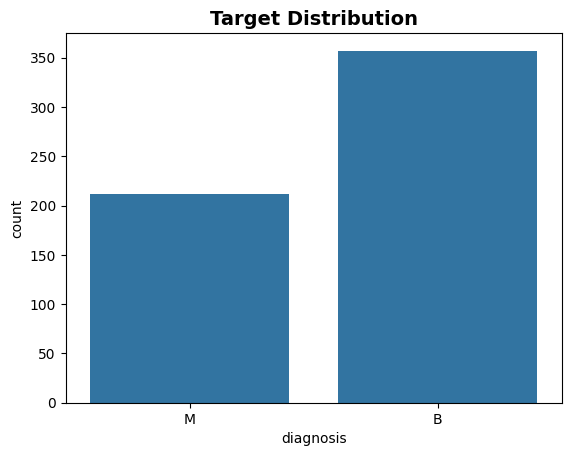

In [51]:
sns.countplot(x=df['diagnosis'])
plt.title("Target Distribution", fontsize=14, fontweight='bold')
plt.show()

In [52]:
df['diagnosis']=df['diagnosis'].apply(lambda x:1 if x=='M' else 0)

In [53]:
df.shape[1]

31

In [54]:
import numpy as np

In [55]:
remaining_cols=df.select_dtypes(include=[np.number]).columns.tolist()

In [56]:
zero_missing_cols=[]
zero_missing_category=[]
category_cols=[]

In [57]:
print(remaining_cols)

['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [58]:
remaining_cols.remove('diagnosis')

In [59]:
print(remaining_cols)

['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [60]:
transformers=[]
if zero_missing_cols:
  impute_then_scale=SklearnPipeline([
      ("KNN_Imputer", KNNImputer(n_neighbors=5)),
      ("Scaler", StandardScaler())
  ])
  transformers.append(("Impute_then_scale", impute_then_scale, zero_missing_cols))

  remaining_columns=[c for c in remaining_cols if c not in zero_missing_cols]
  transformers.append("scaler_all", SklearnPipeline([("scaler", StandardScaler())]), remaining_columns)
else:
  transformers.append(("scaler_all", SklearnPipeline([("scaler", StandardScaler())]), remaining_cols))

if zero_missing_category:
  impute_cat_scale=SklearnPipeline([
      ("Imputer", SimpleImputer(strategy='most frequent')),
      ("OneHotEncoder", OneHotEncoder(handle_unknown='ignore', drop='first'))
  ])
  transformers.append(("impute_cat_scale", impute_cat_scale, zero_missing_category))
  remaining_after_impute=[c for c in category_cols if c not in zero_missing_category]
  transformers.append(("Ohe_scale", SklearnPipeline([("OneHotEncode", OneHotEncoder(handle_unknown='ignore', drop='first'))]), remaining_after_impute))
else:
  transformers.append(("Ohe_scale", SklearnPipeline([("OneHotEncode", OneHotEncoder(handle_unknown='ignore', drop='first'))]), category_cols))

In [61]:
print(transformers)

[('scaler_all', Pipeline(steps=[('scaler', StandardScaler())]), ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']), ('Ohe_scale', Pipeline(steps=[('OneHotEncode',
                 OneHotEncoder(drop='first', handle_unknown='ignore'))]), [])]


In [62]:
preprocessor=ColumnTransformer(transformers=transformers, remainder='drop')

#Training

In [63]:
X=df.drop(columns=['diagnosis'])
y=df['diagnosis']

In [64]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [65]:
k=5
knn=KNeighborsClassifier(n_neighbors=k)

In [66]:
pipeline=SklearnPipeline([("preprocessor", preprocessor), ("knn", knn)])

In [67]:
print(X.columns)

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [68]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler_all',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['radius_mean',
                                                   'texture_mean',
                                                   'perimeter_mean',
                                                   'area_mean',
                                                   'smoothness_mean',
                                                   'compactness_mean',
                                                   'concavity_mean',
                                                   'concave points_mean',
                                                   'symmetry_mean',
                                                   'fractal_dimension_mean',
                                                   'radius_se', 'texture_se',
                                                   'perimeter_se', 'area_se',
                                                   '...
                                                   'symmetry_se',
                                                   'fractal_dimension_se',
                                                   'radius_worst',
                                                   'texture_worst',
                                                   'perimeter_worst',
                                                   'area_worst',
                                                   'smoothness_worst',
                                                   'compactness_worst',
                                                   'concavity_worst',
                                                   'concave points_worst',
                                                   'symmetry_worst',
                                                   'fractal_dimension_worst']),
                                                 ('Ohe_scale',
                                                  Pipeline(steps=[('OneHotEncode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  [])])),
                ('knn', KNeighborsClassifier())])

Save Artefacts

In [69]:
import joblib
joblib.dump(pipeline, "KNNClassifier.pkl")

['KNNClassifier.pkl']

#Evaluation

In [70]:
y.head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


In [71]:
y_train_predict=pipeline.predict(X_train)
y_test_predict=pipeline.predict(X_test)

In [72]:
y_train_proba=pipeline.predict_proba(X_train)[:, 1]

In [73]:
print(y_train_proba)

[1.  0.  0.  1.  1.  1.  0.  0.8 0.8 1.  1.  1.  0.  1.  0.  0.  0.  0.
 0.  0.  0.  0.2 1.  0.2 1.  0.  1.  0.  1.  1.  0.  0.  1.  1.  0.  0.
 0.  0.6 0.  0.  0.8 0.  0.  1.  0.  1.  0.  0.  0.  0.  0.  0.  1.  0.6
 1.  1.  0.8 0.  1.  0.  1.  1.  0.  0.  0.  1.  0.2 0.  1.  0.  0.  0.
 1.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.4 0.  0.  0.  0.
 0.  0.  1.  0.  0.  1.  1.  0.  0.  0.2 0.  0.  1.  0.  0.  0.  1.  0.
 0.8 1.  1.  0.  0.  0.  0.  0.  1.  0.  0.  1.  1.  0.  1.  0.  1.  0.
 0.  1.  0.  0.  1.  1.  0.  0.  0.  0.  1.  0.4 1.  0.2 0.  0.8 1.  0.
 1.  1.  1.  0.  1.  0.  0.  1.  1.  0.  0.  0.  1.  0.  0.2 0.  0.2 0.
 0.  0.  0.  1.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  1.  0.  1.  1.
 1.  0.  0.  1.  1.  0.  0.  1.  0.  1.  0.  1.  0.2 1.  0.  0.2 1.  0.
 0.  1.  0.  0.2 0.  0.  0.  0.  0.  1.  1.  0.6 0.2 0.  1.  0.  0.8 0.
 0.  0.2 0.2 1.  0.  1.  0.8 0.6 0.  0.  1.  0.  0.  1.  0.6 0.  0.  1.
 1.  1.  0.  1.  0.  0.  0.  0.  0.4 0.  0.  1.  1.  0.  1.  0.

In [74]:
y_test_proba=pipeline.predict_proba(X_test)[:, 1]

In [75]:
print(y_test_proba)

[0.  1.  0.  0.2 0.  0.  0.8 0.  0.  0.  0.8 0.  1.  0.  0.2 0.  0.  0.
 0.6 0.  0.  0.  1.  1.  0.6 0.  0.  0.8 1.  1.  1.  0.  1.  1.  0.  0.
 0.  0.  1.  0.  0.  0.  0.2 0.  0.  1.  0.2 0.6 0.  0.  1.  1.  0.  0.
 0.  0.6 0.2 0.  0.  1.  0.  0.  1.  0.  0.  0.  1.  1.  0.  0.8 0.  1.
 1.  0.  0.  0.  0.  1.  0.  0.6 1.  1.  0.  0.  0.  0.  1.  1.  1.  0.
 1.  0.  0.4 0.  0.  0.  0.  0.6 0.  0.  0.  0.  0.  0.  0.  0.  1.  0.
 1.  0.  0.  0.2 0.2 1. ]


In [76]:
(y_test_proba>=0.9).astype(int)

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1])

In [77]:
train_results=X_train.copy()
train_results['actual']=y_train.values
train_results['predicted']=y_train_predict
train_results['probability']=y_train_proba

In [78]:
print(train_results.head())

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
10         16.02         23.24          102.70      797.8          0.08206   
170        12.32         12.39           78.85      464.1          0.10280   
407        12.85         21.37           82.63      514.5          0.07551   
430        14.90         22.53          102.10      685.0          0.09947   
27         18.61         20.25          122.10     1094.0          0.09440   

     compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
10            0.06669         0.03299              0.03323         0.1528   
170           0.06981         0.03987              0.03700         0.1959   
407           0.08316         0.06126              0.01867         0.1580   
430           0.22250         0.27330              0.09711         0.2041   
27            0.10660         0.14900              0.07731         0.1697   

     fractal_dimension_mean  ...  area_worst  smoothness_worst  \
10

In [79]:
test_results=X_test.copy()
test_results['actual']=y_test.values
test_results['predicted']=y_test_predict
test_results['probability']=y_test_proba

In [80]:
print(test_results.head())

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
120        11.41         10.82           73.34      403.3          0.09373   
250        20.94         23.56          138.90     1364.0          0.10070   
375        16.17         16.07          106.30      788.5          0.09880   
99         14.42         19.77           94.48      642.5          0.09752   
455        13.38         30.72           86.34      557.2          0.09245   

     compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
120           0.06685         0.03512              0.02623         0.1667   
250           0.16060         0.27120              0.13100         0.2205   
375           0.14380         0.06651              0.05397         0.1990   
99            0.11410         0.09388              0.05839         0.1879   
455           0.07426         0.02819              0.03264         0.1375   

     fractal_dimension_mean  ...  area_worst  smoothness_worst  \
12

In [81]:
test_results[test_results['actual']!=test_results['predicted']]

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,actual,predicted,probability
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,826.4,0.1431,0.3026,0.3194,0.1565,0.2718,0.09353,1,0,0.2
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,...,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.10300,1,0,0.0
208,13.11,22.54,87.02,529.4,0.10020,0.14830,0.08705,0.05102,0.1850,0.07310,...,639.3,0.1349,0.4402,0.3162,0.1126,0.4128,0.10760,0,1,0.6
385,14.60,23.29,93.97,664.7,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,...,758.2,0.1312,0.1581,0.2675,0.1359,0.2477,0.06836,1,0,0.2
205,15.12,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,...,989.5,0.1491,0.3331,0.3327,0.1252,0.3415,0.09740,1,0,0.2


In [82]:
test_results.groupby(['actual', 'predicted']).size()

actual  predicted
0       0            71
        1             1
1       0             4
        1            38
dtype: int64

In [83]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [84]:
def calculate_matrics(y_actual, y_pred):
  return {
      "Accuracy":accuracy_score(y_actual, y_pred),
      "Precision":precision_score(y_actual, y_pred, zero_division=0),
      "Recall":recall_score(y_actual, y_pred, zero_division=0),
      "f1_score":f1_score(y_actual, y_pred, zero_division=0),
      "Confusion_matrix":confusion_matrix(y_actual, y_pred),
  }

In [85]:
results=calculate_matrics(y_test, y_test_predict)

In [86]:
for k, v in results.items():
  if k not in ('Confusion_matrix', ):
    print(f"  {k}:{v:.4f}")

  Accuracy:0.9561
  Precision:0.9744
  Recall:0.9048
  f1_score:0.9383


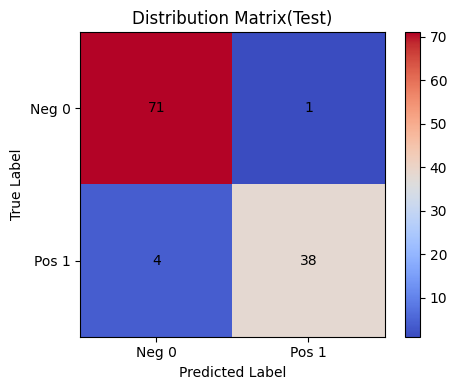

In [87]:
metrics_test=results['Confusion_matrix']
plt.figure(figsize=(5, 4))
plt.imshow(metrics_test, interpolation='nearest', cmap='coolwarm')
plt.title("Distribution Matrix(Test)")
plt.colorbar()
plt.xticks([0, 1], ["Neg 0", "Pos 1"])
plt.yticks([0, 1], ["Neg 0", "Pos 1"])
for i in range(metrics_test.shape[0]):
  for j in range(metrics_test.shape[1]):
    plt.text(j, i, metrics_test[i, j], ha='center', va='center')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

#Finding Optimal Value of K

Elbow method to choose K

In [88]:
import numpy as np

In [91]:
accuracy_test=[]
error_rates=[]
k_range=range(1, 21)
for k in k_range:
  knn=KNeighborsClassifier(n_neighbors=k)
  pipeline=SklearnPipeline([("Preprocessor", preprocessor), ("knn", knn)])
  pipeline.fit(X_train, y_train)
  y_test_pred=pipeline.predict(X_test)
  accuracy=accuracy_score(y_test, y_test_pred)
  error=np.mean(y_test_pred!=y_test)
  accuracy_test.append(accuracy)
  error_rates.append(error)

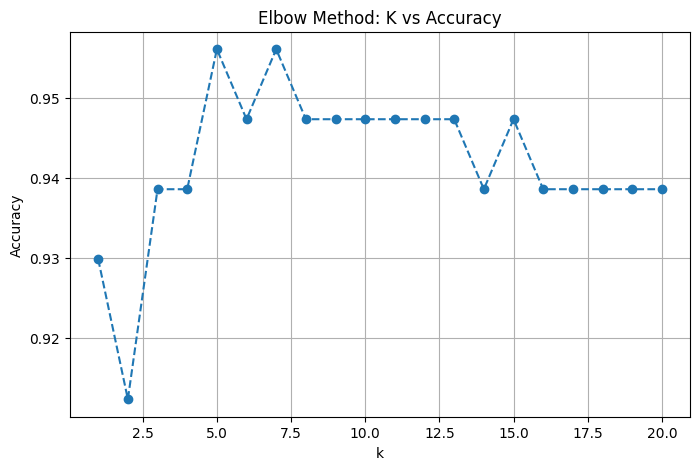

In [99]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, accuracy_test, marker='o', linestyle='--')
plt.title("Elbow Method: K vs Accuracy")
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

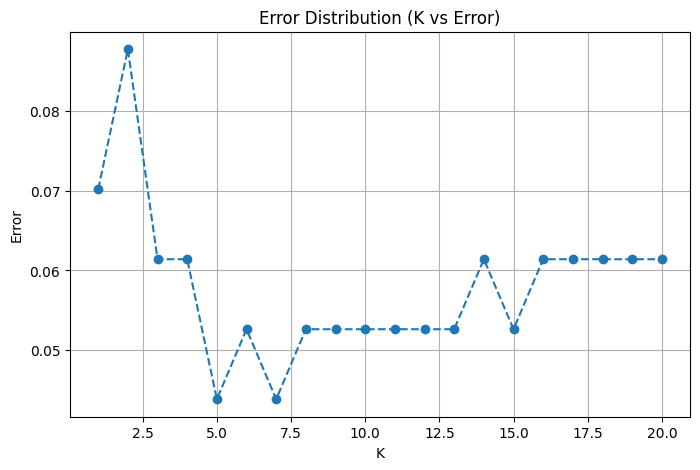

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, error_rates, marker='o', linestyle='--')
plt.title("Error Distribution (K vs Error)")
plt.xlabel("K")
plt.ylabel("Error")
plt.grid(True)
plt.show()

#Cross Validation to find the best value of K

In [100]:
from sklearn.model_selection import cross_val_score

In [101]:
cv_scores=[]
k_range=range(1, 21)
for k in k_range:
  knn=KNeighborsClassifier(n_neighbors=k)
  pipeline=SklearnPipeline([("preprocessor", preprocessor), ("knn", knn)])
  scores=cross_val_score(pipeline, X, y, cv=10, scoring='accuracy')
  print(f"Nearest neighbors selected :{k}, mean_scores:{scores.mean()}, scores for each fold:{scores.tolist()}")
  cv_scores.append(scores.mean())

Nearest neighbors selected :1, mean_scores:0.9507518796992482, scores for each fold:[0.9649122807017544, 0.9298245614035088, 0.9473684210526315, 0.9824561403508771, 1.0, 0.9473684210526315, 0.9122807017543859, 0.9473684210526315, 0.9473684210526315, 0.9285714285714286]
Nearest neighbors selected :2, mean_scores:0.9560463659147869, scores for each fold:[1.0, 0.9122807017543859, 0.9473684210526315, 0.9824561403508771, 0.9649122807017544, 0.9649122807017544, 0.9122807017543859, 0.9473684210526315, 0.9824561403508771, 0.9464285714285714]
Nearest neighbors selected :3, mean_scores:0.9647869674185465, scores for each fold:[0.9824561403508771, 0.9649122807017544, 0.9473684210526315, 0.9824561403508771, 1.0, 0.9824561403508771, 0.9298245614035088, 0.9649122807017544, 0.9649122807017544, 0.9285714285714286]
Nearest neighbors selected :4, mean_scores:0.963063909774436, scores for each fold:[0.9824561403508771, 0.9649122807017544, 0.9298245614035088, 0.9824561403508771, 1.0, 0.9649122807017544, 0

In [102]:
best_k=k_range[np.argmax(cv_scores)]
print(f"Best k using cross validation:{best_k}")
print(f"Cross-Validation accuracy for k={best_k}:{max(cv_scores):.4f}")

Best k using cross validation:5
Cross-Validation accuracy for k=5:0.9666


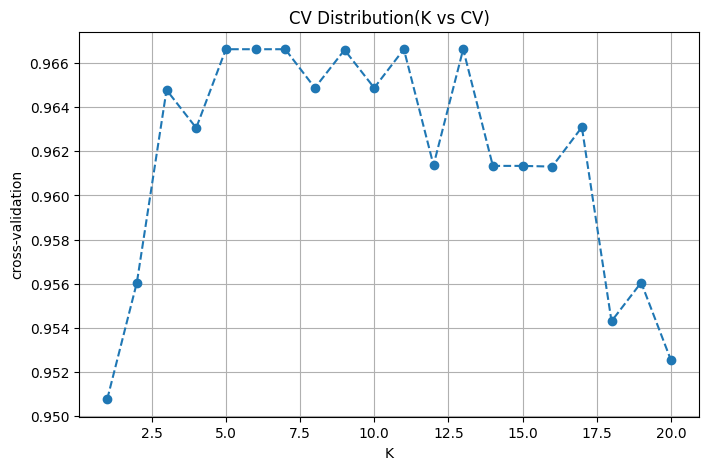

In [104]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o', linestyle='--')
plt.title("CV Distribution(K vs CV)")
plt.xlabel("K")
plt.ylabel("cross-validation")
plt.grid(True)
plt.show()

#SVM

In [105]:
from sklearn.svm import SVC

In [107]:
svm_models={
    "Linear":SVC(kernel='linear', C=1.0, random_state=20),
    "Poly":SVC(kernel='poly', degree=3, C=1.0, random_state=20),
    "RBF":SVC(kernel='rbf', C=1.0, gamma="scale", random_state=20)
}

In [108]:
results=[]

In [112]:
for name, model in svm_models.items():
  pipeline=SklearnPipeline([("preprocessor", preprocessor), ("Model", model)])
  pipeline.fit(X_train, y_train)
  y_train_pred=pipeline.predict(X_train)
  y_test_pred=pipeline.predict(X_test)
  train_acc=accuracy_score(y_train, y_train_pred)
  test_acc=accuracy_score(y_test, y_test_pred)
  results.append([name, train_acc, test_acc])
  print(f"{name} SVM")
  print(f"    Train Accuracy:{train_acc:.4f}")
  print(f"    Test Accuracy:{test_acc:.4f}")
  print("="*40)

Linear SVM
    Train Accuracy:0.9890
    Test Accuracy:0.9649
Poly SVM
    Train Accuracy:0.9121
    Test Accuracy:0.8860
RBF SVM
    Train Accuracy:0.9868
    Test Accuracy:0.9737
